# Anomaly Dection(异常检测)
我们将会使用一个高斯模型检测数据集里的异常样本，我们首先以一个二维数据集开始，以便可视化让我们知道我们在做什么，之后我们应用异常检测算法到一个更大的、维度更多的数据集

In [2114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat


In [2115]:
data1 = loadmat('data/ex8data1.mat')
data2 = loadmat('data/ex8data2.mat')
data1
# 'X' 'Xval' 'yval'


{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Thu Dec  1 15:37:10 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[13.04681517, 14.74115241],
        [13.40852019, 13.7632696 ],
        [14.19591481, 15.85318113],
        [14.91470077, 16.17425987],
        [13.57669961, 14.04284944],
        [13.92240251, 13.40646894],
        [12.82213164, 14.22318782],
        [15.67636615, 15.89169137],
        [16.16287532, 16.20299807],
        [12.66645095, 14.89908374],
        [13.98454962, 12.95800822],
        [14.06146043, 14.54908874],
        [13.38988671, 15.56202142],
        [13.39350475, 15.62698794],
        [13.97900926, 13.28061494],
        [14.16791259, 14.46583829],
        [13.96176145, 14.75182421],
        [14.45899735, 15.07018563],
        [14.58476372, 15.82743424],
        [12.07427074, 13.0671109 ],
        [13.5491294 , 15.53827677],
        [13.98625042, 14.78776304],
        [14.96991942, 16.51830493],
        [14.25576597, 15.294

In [2116]:
X1 = data1['X']
Xval1 = data1['Xval']
yval1 = data1['yval']
# print(yval1)

X2 = data2['X']
Xval2 = data2['Xval']
yval2 = data2['yval']
print(X1.shape,Xval1.shape,yval1.shape)
print(X2.shape,Xval2.shape,yval2.shape)

(307, 2) (307, 2) (307, 1)
(1000, 11) (100, 11) (100, 1)


X 是 train set Xval y val 是 cross validation set

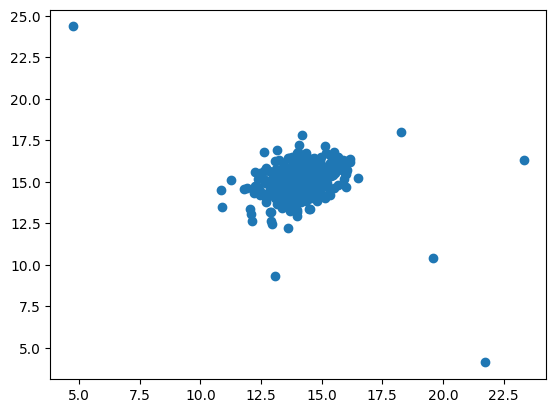

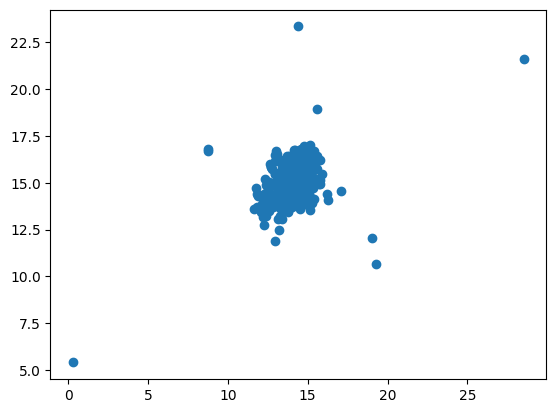

In [2117]:
plt.scatter(X1[:,0],X1[:,1])
plt.show()
plt.scatter(Xval1[:,0],Xval1[:,1])
plt.show()

### 均值估计
$$\mu_i = \frac{1}{m} \sum_{j=1}^m x_i^{(j)}$$

### 方差估计  
$$\sigma_i^2 = \frac{1}{m} \sum_{j=1}^m (x_i^{(j)} - \mu_i)^2$$

In [2118]:
m,n = X1.shape
mu = np.sum(X1,axis = 0) / m
sigma_quare = np.sum(np.power((X1-mu),2),axis=0) / (m-1)
print(mu,sigma_quare)
"""
mean = X1.mean(axis = 0)# 按列
var = X1.var(axis = 0)
"""


[14.11222578 14.99771051] [1.83862041 1.71533273]


'\nmean = X1.mean(axis = 0)# 按列\nvar = X1.var(axis = 0)\n'

### Gaussian高斯分布
$$ p(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}, $$

下面假设了各个特征值之间相互独立

In [2119]:
def Gussian(X:np.ndarray,mu:np.ndarray,sigma_q:np.ndarray)->np.ndarray:
    return np.exp(-np.power((X-mu),2) / (2*sigma_q)) / np.sqrt(2 * np.pi * sigma_q)
p = Gussian(X1,mu,sigma_quare)
print(p)
# coumpute p(x)
p = p[:,0] * p [:,1]
print (p)
p.shape




[[2.16075205e-01 2.98815650e-01]
 [2.57145578e-01 1.95357242e-01]
 [2.93654628e-01 2.46088957e-01]
 [2.46950250e-01 2.03469212e-01]
 [2.72140619e-01 2.33514839e-01]
 [2.91345574e-01 1.45612573e-01]
 [1.87111097e-01 2.55737987e-01]
 [1.51258582e-01 2.41303377e-01]
 [9.37605400e-02 1.99449762e-01]
 [1.66646705e-01 3.03741748e-01]
 [2.92913104e-01 9.05867656e-02]
 [2.94008348e-01 2.87248522e-01]
 [2.55294112e-01 2.77602319e-01]
 [2.55656340e-01 2.71398059e-01]
 [2.92797989e-01 1.28970424e-01]
 [2.93966463e-01 2.80494622e-01]
 [2.92408656e-01 2.99283051e-01]
 [2.84748889e-01 3.04138175e-01]
 [2.76880571e-01 2.49221072e-01]
 [9.50933156e-02 1.02778114e-01]
 [2.69908218e-01 2.79733332e-01]
 [2.92947470e-01 3.00715606e-01]
 [2.40869975e-01 1.55249116e-01]
 [2.92570580e-01 2.96894549e-01]
 [1.96017653e-01 2.10354040e-01]
 [1.56597048e-01 1.59025862e-01]
 [2.75513986e-01 2.86248426e-01]
 [2.57189515e-01 2.94402678e-01]
 [2.76276289e-01 2.91702174e-01]
 [2.83068931e-01 2.70003885e-01]
 [1.707080

(307,)

C:\Users\Lam Tim\AppData\Local\Temp\ipykernel_11492\3800182814.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i,j] = Gussian(point, mu, sigma_quare).prod(axis=1)


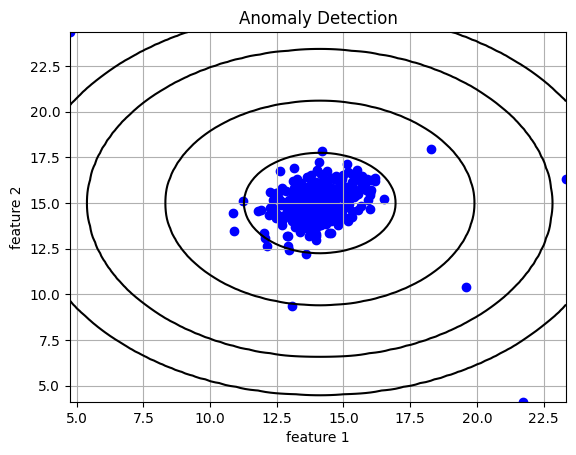

In [2120]:
# plot the propability
y = np.linspace(X1[:,1].min(),X1[:,1].max(),100)
x = np.linspace(X1[:,0].min(),X1[:,0].max(),100)

X,Y=np.meshgrid(x,y)
# 计算网格上每个点的概率
# 不能认为Z = p,Z 是 网格范围内所有点的概率
Z = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        point = np.array([[X[i,j], Y[i,j]]])
        Z[i,j] = Gussian(point, mu, sigma_quare).prod(axis=1)
plt.scatter(X1[:,0],X1[:,1],marker='o',c='b')

# 绘制等高线
contour_level = contour_levels = [10**-15, 10**-10, 10**-5, 0.01, 0.1, 0.5]
plt.contour(X, Y, Z, contour_levels, colors='k')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.title('Anomaly Detection')
# plt.legend()
plt.grid(True)
plt.show()


In [2121]:
# F1 Score
epsilon = 0.01
def judge(x,mu,sigma_quare,epsilon:float)->np.ndarray:
    p = Gussian(x,mu,sigma_quare)
    p = p.prod(axis=1)
    positive = (p <= epsilon)
    y_pred = p.copy()# ！！！否则在python中y_pred是p的引用，p会被修改
    y_pred[positive] = 1
    y_pred[~positive] = 0 # ~positive 将Bool数组中false的元素取反
    return y_pred


- True positive:
predict as positive when it auctually is
- False positive:
predict as positive while it is negative
- False negative:
predict as negative while it is positive
- True negative:
predict as negative when it auctually is

- Precision:
of all the points that are predicted as positive, how many are actually positive?
- Recall:
of all the points that are actually positive, how many are predicted as positive?



In [2122]:

def F1_score(y_true:np.ndarray,y_pred:np.ndarray)->float:
    # 确保输入是一维数组
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    # 计算混淆矩阵指标
    TP = np.sum((y_true == 1) & (y_pred == 1))  # 真正例数量
    FP = np.sum((y_true == 0) & (y_pred == 1))  # 假正例数量
    FN = np.sum((y_true == 1) & (y_pred == 0))  # 假负例数量
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0


In [2123]:

def select_epsilon(x:np.ndarray,mu:np.ndarray,sigma_quare:np.ndarray, y_true:np.ndarray,init_epislon:float = 0.5,toggle_tol:bool = True, max_iter:int = 999, tol:float = 1e-20)->tuple[float,np.ndarray]:
    epsilon = init_epislon
    F1_history = []
    y_pred = judge(x,mu,sigma_quare,epsilon)
    F1_history.append(F1_score(y_true, y_pred))
    flag = 0

    for i in range(max_iter):
        if (flag):
            epsilon = epsilon * 1.05
        else:
            epsilon = epsilon * 0.5
        y_pred = judge(x,mu,sigma_quare,epsilon)
        F1 = F1_score(y_true, y_pred)
        F1_history.append(F1)
        if (F1_history[-1]<F1_history[-2]):
            flag^=1
        if (toggle_tol and i > max_iter / 2 and np.abs(F1_history[-1]-F1_history[-2])<tol):
            break
    return epsilon,np.array(F1_history)


6.530411907011601e-05


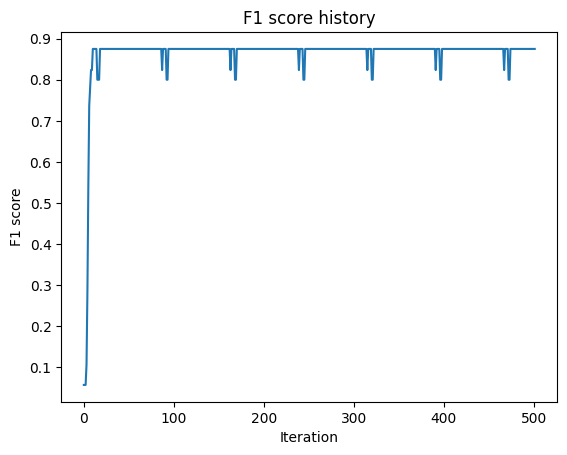

In [2124]:
# 用X得到的mu,sigma去判断Xval1的异常点，Xval充当交叉验证集
epsilon, F1_history = select_epsilon(Xval1,mu,sigma_quare,yval1,init_epislon=0.5)
print(epsilon)
plt.plot(F1_history)
plt.xlabel('Iteration')
plt.ylabel('F1 score')
plt.title('F1 score history')
plt.show()

5.3341723599676085e-05


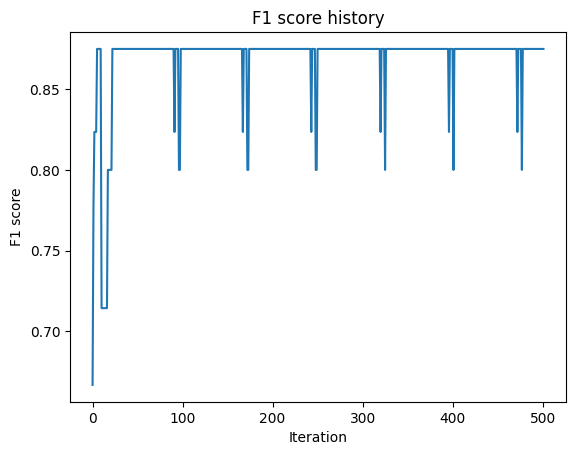

In [2125]:

# 调参
epsilon, F1_history = select_epsilon(Xval1,mu,sigma_quare,yval1,init_epislon=0.01)
print(epsilon)
plt.plot(F1_history)
plt.xlabel('Iteration')
plt.ylabel('F1 score')
plt.title('F1 score history')
plt.show()

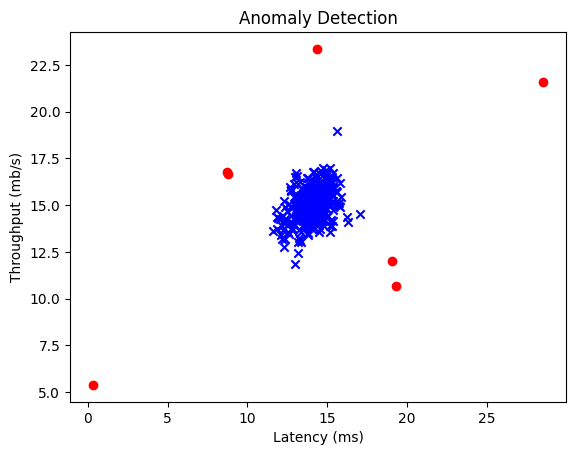

In [2126]:
# 打印异常点
y_pred = judge(Xval1,mu,sigma_quare,epsilon)
plt.scatter(Xval1[y_pred==1][:,0],Xval1[y_pred==1][:,1],c='r',marker='o')
plt.scatter(Xval1[y_pred==0][:,0],Xval1[y_pred==0][:,1],c='b',marker='x')
plt.xlabel('Latency (ms)')
plt.ylabel('Throughput (mb/s)')
plt.title('Anomaly Detection')
plt.show()

### 接下来做一个更大的

2.593706749195542e-19


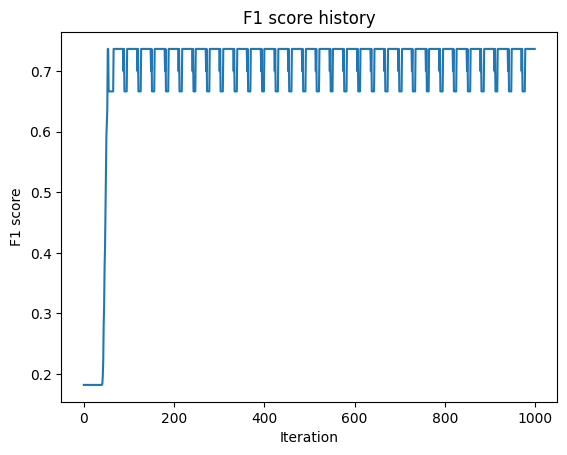

In [2127]:
mu2 = X2.mean(axis=0)
sigma_squre2 = X2.var(axis=0)# 这里我们认为数据独立
epsilon, F1_history = select_epsilon(Xval2,mu2,sigma_squre2,yval2,init_epislon=0.002,toggle_tol=False)
print(epsilon)
plt.plot(F1_history)
plt.xlabel('Iteration')
plt.ylabel('F1 score')
plt.title('F1 score history')
plt.show()



In [2128]:
# 计算准确率
y_pred = judge(Xval2,mu2,sigma_squre2,epsilon)
accuracy = np.mean(y_pred == yval2)
print(accuracy)


0.828
